##### Da wir uns dazu entschieden haben einen Sentence Transformer zu verwenden, behalten wir dieses Notebook als Baseline-Modell bei. Im ersten Schritt wandeln wir Text in Features um. Modelle können keinen Text verstehen, deshalb brauchen wir numerische Features. Hierzu nutzen wir die TF-IDF Methode. Diese gilt als Standard für Sentiment.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

#Wir nutzen hier das bereinigte Datenset
df= pd.read_csv("../data/BMW/clean_reviews.csv")

In [2]:
df.head()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,company
0,fb7fb9f2-75ad-4660-8c9d-ad05bae0739d,every time i tap on the widget to open the app...,3,0,5.11.4,2026-03-07 16:35:07,5.11.4,BMW
1,86b51f94-88da-42b0-87ac-fcbe94e86ea8,i have a vehicle with comfort access and a sam...,2,0,5.11.4,2026-03-07 14:42:54,5.11.4,BMW
2,20f31dc9-de57-46c7-b503-2fdc2ca757c4,can't add my e34 and e39 :/,1,0,5.11.4,2026-03-07 09:50:37,5.11.4,BMW
3,dffdfe4f-70a8-40f2-b684-ba6a5858fe55,bmw stands for its reliability n performance i...,5,0,5.11.3,2026-03-07 07:47:33,5.11.3,BMW
4,4c00e344-ebb7-486d-b0ed-8ef2b0fa0cbb,the lack of support for octopus intelligent go...,2,0,5.11.4,2026-03-06 19:38:16,5.11.4,BMW


In [3]:
df.isna().sum()

reviewId                  0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    556
at                        0
appVersion              556
company                   0
dtype: int64

##### Einige Reviews enthalten keine Informationen über die verwendete App-Version. Da Versionsinformationen für die Sentiment-klassifikation nicht erforderlich sind, wurden diese Reviews im Datensatz beibehalten. Diese sollten nur für Analysen wie (Rating pro Version, Update Impact und Version Comparison) bereinigt werden.

##### Im nächsten Schritt definieren wir die Target Variablen, also Sentiment aus dem Rating.

In [4]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"
    
df["sentiment"] = df["score"].apply(sentiment_label)

In [5]:
#Klassenverteilung prüfen
df["sentiment"].value_counts(normalize=True)

sentiment
positive    0.525454
negative    0.384908
neutral     0.089637
Name: proportion, dtype: float64

##### Anschließend machen wir den Train/Test Split und nehmen die Vektoriesierung im Anschluss vor

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

##### Nun erstellen wir unser erstes Modell. Wir beginnen mit LogisticRegression.

In [7]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [8]:
# sehen wie viele Itertionen gebraucht wurden
print(log_model.n_iter_)

[57]


In [9]:
# Wir erstellen hier die Prediction für das Logistic Regression Modell (Evaluation)
from sklearn.metrics import classification_report
y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

    negative       0.75      0.90      0.82       809
     neutral       0.33      0.02      0.03       188
    positive       0.88      0.89      0.89      1105

    accuracy                           0.82      2102
   macro avg       0.65      0.60      0.58      2102
weighted avg       0.78      0.82      0.78      2102



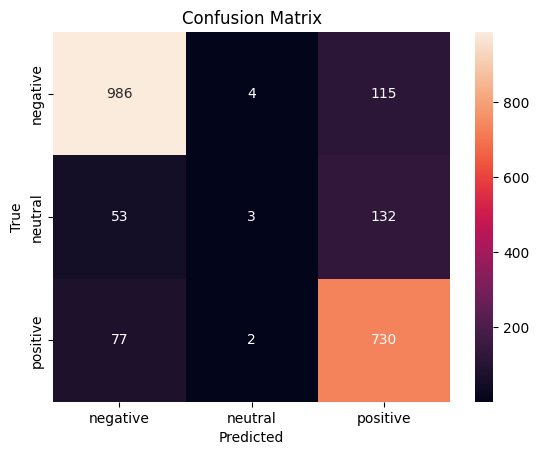

In [10]:
# Hier erstellen wir die Confusion Matrix für das Logistic Regression Modell
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm= confusion_matrix(y_test, y_pred_log, labels=["positive", "neutral", "negative"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=log_model.classes_, yticklabels=log_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

##### Interpretation Confusion Matrix Linear Regression Modell
- Zeilen = echte Labels (True)
- Spalten = Modellvorhersage (Predicted)

- Echte negative Reviews: 952+3+118=1073 --> Davon korrekt erkannt: 952, als positiv klassifiziert = 118, als neutral klassifiziert = 3
- Interpretation: Das Modell erkennt negative Reviews sehr gut, aber manchmal werden negative Reviews als positiv interpretiert.
Das passiert oft bei Sätzen wie: Great app but crashes sometimes.
- Echte neutrale reviews: 59+4+115=178 --> Davon korrekt erkannt: 4
- Interpretation: Das Modell erkennt Neutralität sehr schlecht. Das ist normal bei Sentiment-Modellen, weil neutrale Reviews oft schwer zu unterscheiden sind.
- Echte positive Reviews: 107+2+740=849 -->Davon korrekt erkannt: 740, als negativ klassifizeirt: 107, als neutral klassifiziert: 2
- Interpretation: Das Modell erkennt positive Reviews sehr gut.
- Gesamtinterpretation: Das Modell ist gut bei positive, negative aber schlecht bei neutral. Das ist sehr typisch für Sentimentanalyse. Viele Studien machen deshalb nur negative vs positive.
- Unser Modell ist mit einer accuracy von fast 80% sehr solide.

##### Zum Vergleich testen wir noch das Linear SVM Modell.

In [11]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(max_iter=5000)
svm_model.fit(X_train, y_train)


/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(max_iter=5000)

In [12]:
# sehen wie viele Itertionen gebraucht wurden
print(svm_model.n_iter_)

45


In [13]:
# Wir erstellen hier die Prediction für das SVM Modell und den Classification Report (Evaluation)
from sklearn.metrics import classification_report
y_pred_svm= svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

    negative       0.76      0.89      0.82       809
     neutral       0.29      0.09      0.13       188
    positive       0.89      0.89      0.89      1105

    accuracy                           0.82      2102
   macro avg       0.65      0.62      0.61      2102
weighted avg       0.79      0.82      0.79      2102



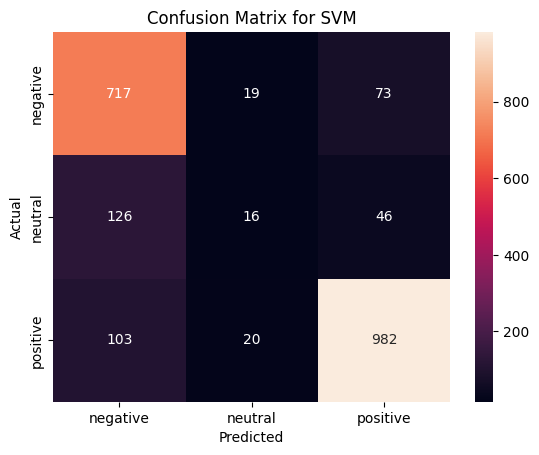

In [14]:
# Hier erstellen wir die Confusion Matrix für das SVM Modell
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm= confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for SVM")
plt.show()

##### Interpretation Confusion Matrix SVM Modell


In [15]:
# Hier vergleichen wir die accuracy der beiden Modelle
from sklearn.metrics import accuracy_score
print("Logistic Regression Classification Report:",accuracy_score(y_test, y_pred_log))
print("SVM Classification Report:",accuracy_score(y_test, y_pred_svm))

Logistic Regression Classification Report: 0.8177925784966699
SVM Classification Report: 0.8158896289248335


##### Nachfolgend ermitteln wir mithilfe von GridsearchCV die besten Hyperparameter für unsere Modelle

In [16]:
#GridSearchCV für Logistic Regression Modell
from sklearn.model_selection import GridSearchCV

param_grid_log= {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}
grid_log= GridSearchCV(LogisticRegression(max_iter=1000,class_weight="balanced"), param_grid_log, cv=5, scoring="accuracy")
grid_log.fit(X_train, y_train)
print("Best Parameters for Logistic Regression:", grid_log.best_params_)
print("Best Score for Logistic Regression:", grid_log.best_score_)

Best Parameters for Logistic Regression: {'C': 10, 'solver': 'liblinear'}
Best Score for Logistic Regression: 0.8088503318547294


In [17]:
#Wir evaluieren anschließend das Logistic Regression Modell mit den besten Hyperparametern
best_log_model = grid_log.best_estimator_
y_pred_best_log = best_log_model.predict(X_test)
print(classification_report(y_test, y_pred_best_log))

              precision    recall  f1-score   support

    negative       0.77      0.87      0.81       809
     neutral       0.25      0.16      0.20       188
    positive       0.91      0.88      0.89      1105

    accuracy                           0.81      2102
   macro avg       0.64      0.64      0.64      2102
weighted avg       0.80      0.81      0.80      2102



In [18]:
#GridSearchCV für SVM Modell
param_grid_svm= {
    "C": [0.01, 0.1, 1, 10]}
grid_svm= GridSearchCV(LinearSVC(class_weight="balanced",max_iter=5000), param_grid_svm, cv=5, scoring="accuracy")
grid_svm.fit(X_train, y_train)
print("Best Parameters for SVM:", grid_svm.best_params_)
print("Best Score for SVM:", grid_svm.best_score_)

/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of 

Best Parameters for SVM: {'C': 0.1}
Best Score for SVM: 0.8067079713748327


/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [19]:
#Wir evaluieren anschließend das SVM Modell mit den besten Hyperparametern
best_svm_model = grid_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test)
print(classification_report(y_test, y_pred_best_svm))

              precision    recall  f1-score   support

    negative       0.75      0.88      0.81       809
     neutral       0.29      0.16      0.21       188
    positive       0.91      0.87      0.89      1105

    accuracy                           0.81      2102
   macro avg       0.65      0.64      0.64      2102
weighted avg       0.79      0.81      0.80      2102



In [20]:
#Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_svm_model, X_train, y_train, cv=5)

print("Cross validation scores:", scores)
print("Mean CV score:", scores.mean())

Cross validation scores: [0.80915577 0.81034483 0.80904224 0.80606782 0.79892921]
Mean CV score: 0.8067079713748327


/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of 

##### Modellvergleich und Auswahl des finalen Modells
Sowohl Logistic Regression als auch Linear SVM erzielten eine sehr ähnliche Leistung mit einer Genauigkeit von etwas 80%. Allerdings schnitt das Linear-SVM-Modell leicht besser ab als die Logistic Regression. Aus diesem Grund wurde Linear SVM als finales Modell für die Sentimentklassifikation ausgewählt.

Nachfolgend schauen wir uns die wichtigsten Wörter im Modell an.

In [21]:
feature_names = vectorizer.get_feature_names_out()
coefficients = best_svm_model.coef_
for i, label in enumerate(best_svm_model.classes_):
    top10 = coefficients[i].argsort()[-10:]
    print(f"Top 10 words for {label}:")
    for j in top10:
        print(feature_names[j])

Top 10 words for negative:
ständig
keeps
login
poor
keine
useless
no
doesn
not
nicht
Top 10 words for neutral:
to km
aber
sometimes
verbrauch
leider
missing
why
ok
however
but
Top 10 words for positive:
useful
excellent
top
alles
gute
easy
love
gut
super
great


### Wir speichern das Modell

In [22]:
import joblib

joblib.dump(best_svm_model, "../models/sentiment_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']